# Study of Attention Mechanism

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
print(f'Import PyTorch V{torch.__version__}')

dev = torch.device(type='cuda') if torch.cuda.is_available() else torch.device(type='cpu')
print(f'Use device {dev}')

Import PyTorch V2.1.1
Use device cuda


In [2]:
from d2l import torch as d2l
d2l.use_svg_display()

## Queries, Keys, and Values

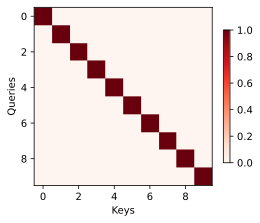

In [3]:
attention_weights = torch.eye(10).reshape(1, 1, 10, 10)
d2l.show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries', figsize=(4.0, 4.0))

## Attention Pooling by Similarity

In [4]:
# Define some kernels
def gaussian(x):
    return torch.exp(-x**2 / 2)

def boxcar(x):
    return torch.abs(x) < 1.0

def constant(x):
    return 1.0 + 0 * x

def epanechikov(x):
    return torch.max(1 - torch.abs(x), torch.zeros_like(x))

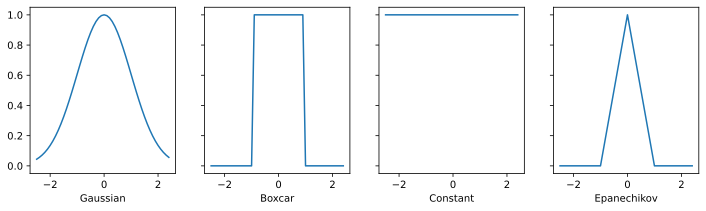

In [5]:
fig, axes = d2l.plt.subplots(1, 4, sharey=True, figsize=(12, 3))

kernels = (gaussian, boxcar, constant, epanechikov)
names = ('Gaussian', 'Boxcar', 'Constant', 'Epanechikov')
x = torch.arange(-2.5, 2.5, 0.1)

for kernel, name, ax in zip(kernels, names, axes):
    ax.plot(x.detach().numpy(), kernel(x).detach().numpy())
    ax.set_xlabel(name)

d2l.plt.show()

In [6]:
print('prepare training and validation data')

def f(x):
    """target function"""
    return 2 * torch.sin(x) + x

n = 50
xmax = 5.0
sigma = 1.0

x_train, _ = torch.sort(torch.rand(n) * xmax)
y_train = f(x_train) + torch.randn(n) * sigma

x_val = torch.arange(0.0, xmax, xmax / 100.0)
y_val = f(x_val)

prepare training and validation data


In [7]:
print('define Nadaraya-Watson regression')

def nadaraya_watson(x_train, y_train, x_val, kernel):
    distances = x_train.reshape((-1, 1)) - x_val.reshape((1, -1)) # generate distance matrix
    k = kernel(distances).type(torch.float32) # perform kernel
    attention_weights = k / k.sum(0) # normalization
    y_hat = y_train @ attention_weights # validation
    return y_hat, attention_weights


define Nadaraya-Watson regression


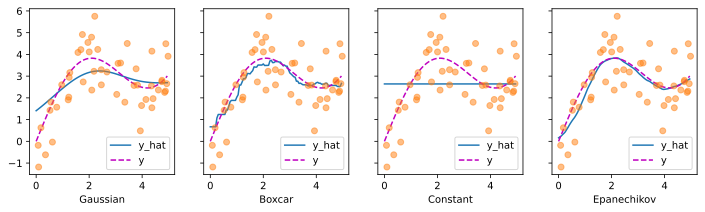

In [8]:
fig, axes = d2l.plt.subplots(1, len(kernels), sharey=True, figsize=(3 * len(kernels), 3))
for kernel, name, ax in zip(kernels, names, axes):
    y_hat, w = nadaraya_watson(x_train, y_train, x_val, kernel)
    ax.plot(x_val, y_hat)
    ax.plot(x_val, y_val, 'm--')
    ax.plot(x_train, y_train, 'o', alpha=0.5)
    ax.set_xlabel(name)
    ax.legend(['y_hat', 'y'])


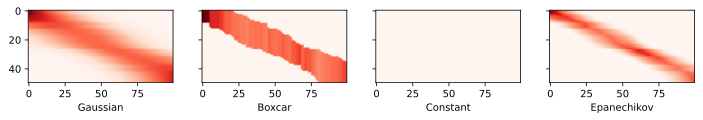

In [9]:
fig, axes = d2l.plt.subplots(1, len(kernels), sharey=True, figsize=(3 * len(kernels), 3))
for kernel, name, ax in zip(kernels, names, axes):
    y_hat, w = nadaraya_watson(x_train, y_train, x_val, kernel)
    pcm = ax.imshow(w.detach().numpy(), cmap='Reds')
    ax.set_xlabel(name)

In [19]:
d2l.masked_softmax(torch.rand(2, 2, 4), torch.tensor([2, 3]))

tensor([[[0.5846, 0.4154, 0.0000, 0.0000],
         [0.3312, 0.6688, 0.0000, 0.0000]],

        [[0.3908, 0.2336, 0.3757, 0.0000],
         [0.3408, 0.2495, 0.4097, 0.0000]]])

In [20]:
Q = torch.randn((2, 3, 4))
K = torch.randn((2, 4, 6))
torch.bmm(Q, K)

tensor([[[ 1.7571, -0.2488, -0.8119,  0.2280,  0.3207,  1.8361],
         [-1.2170, -1.0131,  0.8216,  0.8080,  0.2487, -0.0509],
         [-1.3775,  0.1791, -0.5714,  1.6190,  0.7027, -0.6755]],

        [[ 1.7371, -2.8787,  0.7017,  0.6366,  0.0275,  3.5110],
         [-1.7557,  0.6969,  0.1586, -0.3407, -1.7724, -1.9451],
         [-1.1403, -1.5038, -1.0020, -0.5693, -0.7225, -2.5642]]])